Mean Age: 38.9218
Median Age: 37.0
Std Dev: 10.487806451704609
Range: 74
IQR: 12.0
Skewness: 1.0113202630234552
Kurtosis: 1.3953470615086947


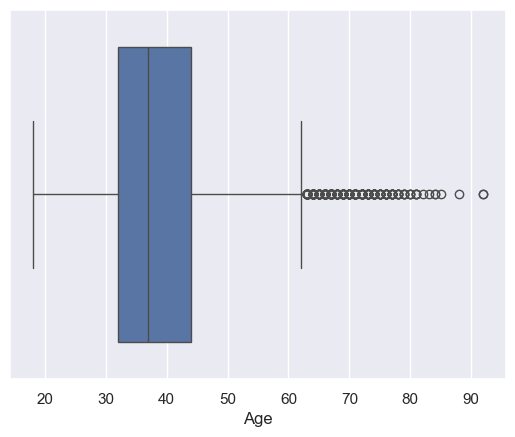

Accuracy: 0.8035


'\n## Future Work\n\n- Apply advanced statistical models\n- Improve feature selection\n- Use real-time data\n\n## Deployment\n\nThe model can be integrated into banking systems for decision support.\n'

In [7]:
##Step 1 — Problem Statement (Markdown)

""" Problem Statement

Customer churn is a major challenge in the banking sector. Retaining customers is more cost-effective than acquiring new ones.

This project applies data science concepts to analyze customer data and predict churn behavior.

The project follows the stages of a data science lifecycle including data collection, preprocessing, analysis, and modeling using statistical and computational techniques.
"""

#Step2 - Dataset Description
""" Dataset Description

The dataset consists of bank customer information including demographic and financial attributes.

Target Variable:
- Exited (1 = customer left, 0 = customer stayed)

The dataset is used to apply statistical analysis, data preprocessing techniques, and regression modeling.
"""

#Step 3 — Data Preprocessing
## Why Python?

"""Python is widely used in data science due to its simplicity and powerful libraries.

Libraries Used:
- NumPy: numerical computation
- Pandas: data handling
- Matplotlib & Seaborn: visualization"""

#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

#Data Collection and Loading
df = pd.read_csv("Churn_Modelling.csv")
df.head()

#Data Cleaning- Usually these columns are useless: they do not help in prediction
df.isnull().sum()
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

#Data Transformation
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
#Data Reduction
df.shape
#Data Discretization
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,50,100], labels=['Young','Adult','Senior'])

#Step 4- Exploratory Data Analysis(EDA)
## Exploratory Data Analysis

#EDA is used to summarize and understand data using descriptive statistics and visualization.
#Descriptive Statistics
df.describe()
print("Mean Age:", df['Age'].mean())
print("Median Age:", df['Age'].median())
print("Std Dev:", df['Age'].std())
print("Range:", df['Age'].max() - df['Age'].min())
print("IQR:", df['Age'].quantile(0.75) - df['Age'].quantile(0.25))
print("Skewness:", df['Age'].skew())
print("Kurtosis:", df['Age'].kurt())
#Box plot
sns.boxplot(x=df['Age'])
plt.show()
#Pivot table
pd.pivot_table(df, values='Balance', index='AgeGroup', columns='Exited', aggfunc='mean')

#Step 5- Build Models
##Linear Regression is used to model the relationship between independent variables and the target variable.
# Step 5 — Model Building

# Select only numeric columns automatically (BEST FIX)
df_model = df.select_dtypes(include=['int64', 'float64'])

# Define X and y
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']


#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int)

#Step 6- Model Evaluation
## Model Evaluation
#Evaluation is done using accuracy and correlation analysis.
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_class))



#Step 7 — Insights & Business Recommendations
## Key Insights
"""
## Insights
- Age shows variation in churn behavior.
- Customers with lower engagement tend to churn more.
- Balance and activity influence customer retention.

## Recommendations

- Focus on high-risk customer groups.
- Improve engagement strategies.
- Provide personalized services.
"""

#Step 8- Conclusion
"""
## Conclusion
The project successfully applied data science concepts such as preprocessing, descriptive statistics, and regression analysis.

Linear regression provided insights into customer churn patterns.

The study demonstrates how statistical and computational methods can support decision-making.

"""

#Step 9- Future Work/DEployment
"""
## Future Work

- Apply advanced statistical models
- Improve feature selection
- Use real-time data

## Deployment

The model can be integrated into banking systems for decision support.
"""
